##### Instructions
- Keep the original structure, you may add additional code cells and/or mark-down cells for clarity, legibility and/or structure.
- Add the required descriptions, explanations, justifications to the mark-down cells. You can find more mark-down tips & tricks online, for example [here](https://jupyter-notebook.readthedocs.io/en/stable/examples/Notebook/Working%20With%20Markdown%20Cells.html) and [here](https://www.ibm.com/docs/en/watson-studio-local/1.2.3?topic=notebooks-markdown-jupyter-cheatsheet)

# EXAM03: Data Science Group Assignment - Iteration 1

**Group name:** [Be Right Back]

**Student names & numbers:**
* [Rick de Cuijper] - [Student no.100097]
* [Bart Geijtenbeek] - [Student no.97543]
* [Boaz Vaneveld] - [Student no.101529]


---

## 0. Iteration setup

**Import libraries**

In [229]:
# CODE CELL: import the necessary libraries for this iteration
# setup the venv by [venv\Scripts\activate]

import pandas as pd;
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import mean_absolute_error, mean_squared_error, root_mean_squared_error

**Load dataset(s)**

In [230]:
# CODE CELL: import the necessary dataset(s) for this iteration
df_ships = pd.read_csv("ships_inventory_iter1.csv");
# sample is used to see proof of loading the correct dataset and to see if the data gets correcty loaded
df_ships.sample(10)

,Ship_ID,Galactic_Credits,Model_Cycle,Ship_Manufacturer,Sector
156859,7308070664,8550,7510.0,Kuat Drive Yards,Ord Ibanna Clouds
1262,7311798829,31799,7515.0,Jumpship Corp,Azimuth Prime
96259,7314039918,4000,7507.0,Independent Shipwrights,Nar Shaddaa Moon
100985,7314147042,21500,7508.0,Corellian Engineering,Florrum Badlands
5746,7314764449,7900,7511.0,Independent Shipwrights,Gamorr Nebula
237855,7316155701,3700,7506.0,Corellian Engineering,Mimban Swamp
87567,7315447061,14500,7514.0,Kuat Drive Yards,Tatooine Binary System
356081,7311310422,35000,7514.0,Corellian Engineering,Florrum Badlands
289043,7311466454,33990,7514.0,Galactic Motors,Onderon Wilds
134640,7306816102,34000,7513.0,Galactic Motrs,Utapau Sinkholes


---

## 1. Business Understanding
*Rubric: LO 6.4D (Reflection on Process)*

#### **Situation Description**

Nebula Brokerage wants to update their current strategy of determining the asking prices for their spaceships. Their dealers currently determine pricing using "gut feelings" and averages. The company is losing credits because of this strategy and have realized this is a risk. Two main reasons have already been identified:

**"Underpricing":** The worth of rare and valuable ships are not being properly recognized, causing them to be sold for less money them they could have potentially earned.

**"Overpricing":** The worth of common ships are being overestimated, causing them to stay in storage because customers are unwilling to pay the high price.

#### **Business Objective(s)**

The goal of this notebook is to establish an accurate data-driven baseline which can be used as a standard reference. Why is this needed in the first place?

The baseline can be used as a reference to determine a "first guess" price for any incoming ships that have not been given a proper look yet. it gives some data to cling onto when no further information is available. Furthemore, this baseline is needed as a comparison for future work. When more complex models are being developed, a baseline is perfect to establish if the model if an actual improvement in the guessing of prices, or if more work needs to be done.

#### **Data Mining Goal(s)**

This is a supervised learning modeling task. The data is labeled and we are trying to make predictions within existing data columns. We know what we are trying to achieve, a baseline model for the "Galactic_Credits" column.

this is also a regression task. The "Galactic_Credits column uses a wide variety of numbers that wouldn't be fit for classification.

#### **Success Criteria**

To make sure the created benchmark is at least accurate to some degree, we will define a succes criteria based on MAE, MSE as well as RMSE. The difference in these metrics will hopefully ensure a better understaning on where the benchmark suceeds and where it falls short. The baseline will be considered a success if it can fulfill the following criteria:

**MAE:** 8.000

**RMSE:** 14.000

The goals for these criteria were chosen somewhat arbitrarily, but should give a good sense if the baseline preforms as needed.

---

## 2. Data Understanding
*Rubric: LO 7.3Q (Visuals) & LO 6.4C (Process)*

**Data exploration**

*Include summary statistics and descriptions of data types below. Describe your findings.*

In [231]:
# CODE CELL: Show basic statistics and information
df_ships.info()
df_ships.describe().T

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 368814 entries, 0 to 368813
Data columns (total 5 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   Ship_ID            368814 non-null  int64  
 1   Galactic_Credits   368814 non-null  int64  
 2   Model_Cycle        361408 non-null  float64
 3   Ship_Manufacturer  368814 non-null  object 
 4   Sector             368814 non-null  object 
dtypes: float64(1), int64(2), object(2)
memory usage: 14.1+ MB


,count,mean,std,min,25%,50%,75%,max
Ship_ID,368814.0,7.311485e+09,4.381124e+06,7.301583e+09,7.308105e+09,7.312604e+09,7.315245e+09,7.317101e+09
Galactic_Credits,368814.0,1.945354e+04,1.554047e+04,5.010000e+02,7.950000e+03,1.599000e+04,2.799000e+04,7.777770e+05
Model_Cycle,361408.0,7.511265e+03,9.078571e+00,7.400000e+03,7.508000e+03,7.513000e+03,7.517000e+03,7.522000e+03


The "ships_inventory" dataset contains 368,814 rows with information on different ships, their cost (Galactic_Credits), model age (Model_Cycle), manufacturer (Ship_Manufacturer), and sector (Sector). The dataset is complete for most columns with the exception of Model_Cycle, which has missing values for 7406 rows.

The columns Galactic_Credits and Model_Cycle contain numerical data. the Galactic_Credits column ranges from 501 to 777777 and represents the price the ships was sold at, while Model_Cycle ranges from 7400 to 7522 and represents the year a ship was built in.

The columns Ship_ID, Ship_Manufacturer and Sector contain categorical, nominal data. The purpose of these columns is mostly evident. Ship_ID contains unique identifiers for every ship. Ship_Manufacturer contains which manufacturer company build the ship. Sector contains which region of space the ship currently resides.

This dataset represents basic information about ships with which simple patterns can already be recognized. Which manufacturer produces on average the most expensive ships, are older ships worth less on average, or does the sector the ship is currently docked at have any connection to the price at which the ship sold?

**Visualizations and patterns**

*Discover patterns in the data by creating visualizations. Create at least a histogram of Galactic_Credits. Describe your observations.*

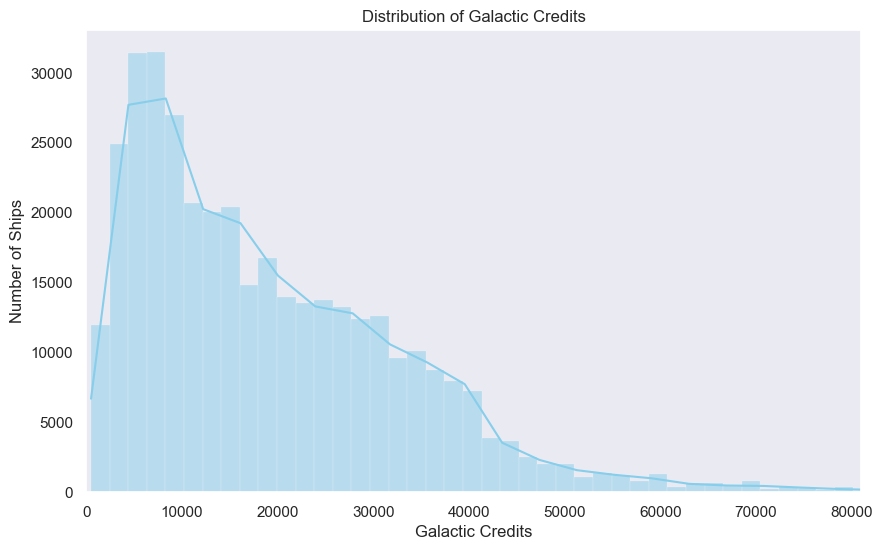

In [232]:
# CODE CELL: Generate visualizations (e.g., scatter plots, histograms)

sns.set_theme(style="dark")

plt.figure(figsize=(10,6))
sns.histplot(df_ships['Galactic_Credits'], bins=400, kde=True, color='skyblue')
plt.title('Distribution of Galactic Credits')
plt.xlabel('Galactic Credits')
plt.ylabel('Number of Ships')
plt.xlim(0, df_ships['Galactic_Credits'].quantile(0.996))
plt.show()

The above histogram neglects to show the top 0,004 percentage of data of the x-axis Galactic_Credits. This decision has been made for the sake of the readability of the histogram. The current histogram shows every value between 0 and 80.000 instead of the original 0 and 800.000 credits as the few datapoints in this range were not visible by eye.

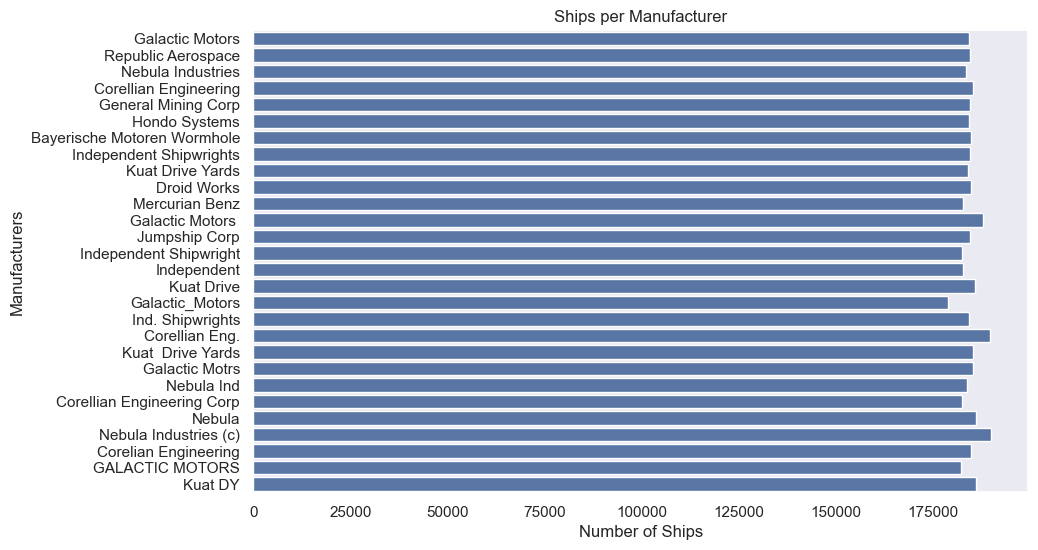

In [233]:
sns.set_theme(style="dark")

plt.figure(figsize=(10,6))
sns.barplot(df_ships['Ship_Manufacturer'], errorbar=None)
plt.title('Ships per Manufacturer')
plt.xlabel('Number of Ships')
plt.ylabel('Manufacturers')
plt.show()

## Data Insights and Data Quality

### Data Insights

- **Visualization: Price distribution:** The distribution is right-skewed, typical of pricing data. Most ships are priced at the lower end of Galactic_Credits with a peak between 5000 and 9000, with a steep drop-off as the price increases. There are a few extremely high-priced ships (outliers), which skew the distribution. This indicates that affordable ships are much more common, while very expensive ships are rare.
- **Manufacturers and sectors:** Some manufacturers produce more ships than others, and certain sectors may have higher concentrations of ships. These patterns can inform market analysis or resource allocation.
- **Model cycle:** The Model_Cycle varies across ships, reflecting the age or technological generation of the ships. Older models may be priced lower.

### Data Quality Issues
- **Visualization: Inconsistencies:** The visualization that shows how many ships each manufacturer produces exposes some issues with the data. Many companies are listed under slightly different names with varying level of detail, as such, this visualization is most likely inaccurate.
- **Missing values:** Model_Cycle has 7,406 missing entries (~2% of the data), which may need imputation or removal.
- **Duplicates:** Ship_ID should be checked for uniqueness to ensure no duplicate entries exist.
- **Outliers:** Extremely high values in Galactic_Credits skew the distribution, which may affect statistical analysis or modeling.
- **Data types:** Numeric and categorical columns are appropriately typed; no major type issues were found.

---

## 3. Data Preparation
*Rubric: LO 6.4C (Data Science Steps)*

**Cleaning and preprocessing**
*Describe and justify steps taken (e.g., imputation, handling outliers, fixing other errors).*

In [234]:
df_ships['Ship_Manufacturer'].unique().tolist()

['Galactic Motors',
 'Republic Aerospace',
 'Nebula Industries',
 'Corellian Engineering',
 'General Mining Corp',
 'Hondo Systems',
 'Bayerische Motoren Wormhole',
 'Independent Shipwrights',
 'Kuat Drive Yards',
 'Droid Works',
 'Mercurian Benz',
 'Galactic Motors ',
 'Jumpship Corp',
 'Independent Shipwright',
 'Independent',
 'Kuat Drive',
 'Galactic_Motors',
 'Ind. Shipwrights',
 'Corellian Eng.',
 'Kuat  Drive Yards',
 'Galactic Motrs',
 'Nebula Ind',
 'Corellian Engineering Corp',
 'Nebula',
 'Nebula Industries (c)',
 'Corelian Engineering',
 'GALACTIC MOTORS',
 'Kuat DY']

In [235]:
# CODE CELL: Data cleaning and preprocessing steps
df_ships['Model_Cycle'].fillna(df_ships['Model_Cycle'].median(), inplace=True)

df_ships.drop_duplicates(subset='Ship_ID', inplace=True)

# Fix inconsistencies
df_ships['Ship_Manufacturer'] = df_ships['Ship_Manufacturer'].str.replace('Galactic Motors ','Replacement_G')
df_ships['Ship_Manufacturer'] = df_ships['Ship_Manufacturer'].str.replace('Galactic Motors','Replacement_G')
df_ships['Ship_Manufacturer'] = df_ships['Ship_Manufacturer'].str.replace('Galactic_Motors','Replacement_G')
df_ships['Ship_Manufacturer'] = df_ships['Ship_Manufacturer'].str.replace('GALACTIC MOTORS','Replacement_G')
df_ships['Ship_Manufacturer'] = df_ships['Ship_Manufacturer'].str.replace('Galactic Motrs','Replacement_G')
df_ships['Ship_Manufacturer'] = df_ships['Ship_Manufacturer'].str.replace('Nebula Industries (c)','Replacement_N')
df_ships['Ship_Manufacturer'] = df_ships['Ship_Manufacturer'].str.replace('Nebula Industries','Replacement_N')
df_ships['Ship_Manufacturer'] = df_ships['Ship_Manufacturer'].str.replace('Nebula Ind','Replacement_N')
df_ships['Ship_Manufacturer'] = df_ships['Ship_Manufacturer'].str.replace('Nebula','Replacement_N')
df_ships['Ship_Manufacturer'] = df_ships['Ship_Manufacturer'].str.replace('Corellian Engineering Corp','Replacement_C')
df_ships['Ship_Manufacturer'] = df_ships['Ship_Manufacturer'].str.replace('Corellian Engineering','Replacement_C')
df_ships['Ship_Manufacturer'] = df_ships['Ship_Manufacturer'].str.replace('Corellian Eng.','Replacement_C')
df_ships['Ship_Manufacturer'] = df_ships['Ship_Manufacturer'].str.replace('Corelian Engineering','Replacement_C')
df_ships['Ship_Manufacturer'] = df_ships['Ship_Manufacturer'].str.replace('Independent Shipwrights','Replacement_I')
df_ships['Ship_Manufacturer'] = df_ships['Ship_Manufacturer'].str.replace('Independent Shipwright','Replacement_I')
df_ships['Ship_Manufacturer'] = df_ships['Ship_Manufacturer'].str.replace('Independent','Replacement_I')
df_ships['Ship_Manufacturer'] = df_ships['Ship_Manufacturer'].str.replace('Ind. Shipwrights','Replacement_I')
df_ships['Ship_Manufacturer'] = df_ships['Ship_Manufacturer'].str.replace('Kuat Drive Yards','Replacement_K')
df_ships['Ship_Manufacturer'] = df_ships['Ship_Manufacturer'].str.replace('Kuat  Drive Yards','Replacement_K')
df_ships['Ship_Manufacturer'] = df_ships['Ship_Manufacturer'].str.replace('Kuat Drive','Replacement_K')
df_ships['Ship_Manufacturer'] = df_ships['Ship_Manufacturer'].str.replace('Kuat DY','Replacement_K')

df_ships['Ship_Manufacturer'] = df_ships['Ship_Manufacturer'].str.replace('Replacement_G','Galactic Motors')
df_ships['Ship_Manufacturer'] = df_ships['Ship_Manufacturer'].str.replace('Replacement_N','Nebula Industries (c)')
df_ships['Ship_Manufacturer'] = df_ships['Ship_Manufacturer'].str.replace('Replacement_C','Corellian Engineering Corp')
df_ships['Ship_Manufacturer'] = df_ships['Ship_Manufacturer'].str.replace('Replacement_I','Independent Shipwrights')
df_ships['Ship_Manufacturer'] = df_ships['Ship_Manufacturer'].str.replace('Replacement_K','Kuat Drive Yards')

print("Missing values:\n", df_ships.isnull().sum())
print("\nData types:\n", df_ships.dtypes)
print("\nNumber of rows after duplicates removed:", len(df_ships))

Missing values:
 Ship_ID              0
Galactic_Credits     0
Model_Cycle          0
Ship_Manufacturer    0
Sector               0
dtype: int64

Data types:
 Ship_ID                int64
Galactic_Credits       int64
Model_Cycle          float64
Ship_Manufacturer     object
Sector                object
dtype: object

Number of rows after duplicates removed: 368314


In [236]:
df_ships['Ship_Manufacturer'].unique().tolist()

['Galactic Motors',
 'Republic Aerospace',
 'Nebula Industries (c)',
 'Corellian Engineering Corp',
 'General Mining Corp',
 'Hondo Systems',
 'Bayerische Motoren Wormhole',
 'Independent Shipwrights',
 'Kuat Drive Yards',
 'Droid Works',
 'Mercurian Benz',
 'Jumpship Corp']

## Data Cleaning and Preprocessing

1. **Handle Missing Values**: Impute missing Model_Cycle values with the median to retain all rows. This method is not ideal, however, there is as of now no real way to figure out when these ships were actually built. Using another model to predict the model cycle using manufacturer and price will only introduce more bias. The missing Model_Cycle rows may as well be left empty.

In [237]:
df_show_duplicates = pd.read_csv("ships_inventory_iter1.csv")

df_show_duplicates[df_show_duplicates.duplicated()]

,Ship_ID,Galactic_Credits,Model_Cycle,Ship_Manufacturer,Sector
19810,7314859162,21495,7517.0,Independent Shipwrights,Florrum Badlands
19931,7312865677,6499,7503.0,Independent Shipwrights,Calodan Expanse
21828,7301737513,25590,7520.0,Independent Shipwrights,Nova Corps Base
23094,7307336208,42990,NaN,Corellian Engineering,Calodan Expanse
26442,7302695176,44590,7518.0,Mercurian Benz,Indoumodo Sector
...,...,...,...,...,...
366051,7316257621,19500,7488.0,Corellian Eng.,Thraxos Blockade
366900,7311470528,32990,7511.0,Corellian Engineering,Wyl Sector
367514,7305944776,18995,7516.0,Kuat Drive Yards,Calodan Expanse
368027,7316612840,3500,7508.0,Galactic Motors,Thraxos Blockade


2. **Remove Duplicates**: Ensure each Ship_ID is unique by dropping duplicate rows. Manual inspection shows that the duplicated Ship_ID rows are identical in every other column as well. It is a safe assumption that the duplication happened by accident and they should thus be removed.

    (Move over to ships_inventory_iter1.csv, press CTRL + F, copy any id below into the searchbox and compare)
    - 7314859162
    - 7312865677
    - 7301737513
    - 7307336208
    - 7302695176

3. **Fix Typos and Inconsistencies**: Change every repeated, yet slightly altered, manufacturer name to the one that is most descriptive. df_ships['Ship_Manufacturer'].unique() was used before the cleanup to identify every name variation and again after the cleanup to verify the results.

4. **Final Check**: Verify missing values, data types, and row counts to ensure the dataset is clean and ready for analysis. df_ships['Ship_Manufacturer'].unique() was used after the cleanup to verify if any inconsistencies had been properly removed.

---

## 4. Modeling
*Rubric: LO 6.4C (Data Science Steps)*

**Model setup**
*Describe and justify the creation of your simple benchmark model to predict Galactic_Credits*

### Model Setup

For predicting `Galactic_Credits`, a **simple benchmark model** was created as a starting point. The purpose of a benchmark model is to provide a baseline performance that more advanced models must exceed.  

**Choice of Model:**  
- A **mean predictor** is used as the simplest benchmark. It is used to predict the average Galactic_Credits for all ships.  
- A **median predictor** is used alongside this. It is used to predict the most common price for all ships
- This approach is easy to implement and sets a reference for model evaluation metrics (e.g., RMSE, MAE).  

**Justification:**  
- Since `Galactic_Credits` is a numeric variable, regression metrics can evaluate the benchmark.  
- Any more complex model (like decision trees or linear regression with features such as `Model_Cycle`, `Ship_Manufacturer`, and `Sector`) should improve upon this baseline.  
- This helps in understanding whether the added complexity of more sophisticated models actually improves predictive performance.

By establishing this benchmark, we can quantitatively measure whether future models are truly effective.

In [240]:
# CODE CELL: Model training and setup code
y = df_ships['Galactic_Credits']

mean_value = y.mean()
median_value = y.median()
y_pred = np.full_like(y, fill_value=mean_value, dtype=float)

mae = mean_absolute_error(y, y_pred)
mse = mean_squared_error(y, y_pred)
rmse = root_mean_squared_error(y, y_pred)

print(f"Benchmark Model (Mean Predictor) Results:")
print(f"Mean Galactic_Credits: {mean_value:.2f}")
print(f"Median Galactic_Credits: {median_value:.2f}")
print(f"MAE: {mae:.2f}")
print(f"MSE: {mse:.2f}")
print(f"RMSE: {rmse:.2f}")

Benchmark Model (Mean Predictor) Results:
Mean Galactic_Credits: 19454.24
Median Galactic_Credits: 15990.00
MAE: 11607.96
MSE: 241573656.84
RMSE: 15542.64


## Benchmark Model: Mean Predictor

- This model predicts the **mean Galactic_Credits** for all ships.  
- It serves as a **baseline** to compare future models.  
- Evaluation metrics:
  - **MAE (Mean Absolute Error)**: Measures average absolute difference between predicted and actual credits.
  - **RMSE (Root Mean Squared Error)**: Measures average squared error, giving more weight to large errors.
- Any more advanced model should aim to improve upon these metrics.

## Benchmark Model: Median Predictor

- This model predicts the **median Galactic_Credits** for all ships. The median is less sensitive to outliers.
- It serves as a **baseline** to compare future models.  
- Any more advanced model should aim to improve upon these metrics.

## Testing and Performance

### Model Testing

For the benchmark model, testing is straightforward because it predicts a constant value (the mean) for all ships. Since no train-test split was applied, the metrics are calculated over the **entire dataset** to establish a baseline.

**Evaluation Metrics:**

| Metric | Value | Interpretation |
|--------|-------|----------------|
| Mean Galactic_Credits | 19454.24 | The model predicts this value for every ship. |
| Median Galactic_Credits | 15990.00 | The model predicts this value for every ship. |
| MAE (Mean Absolute Error) | 11607.96 | On average, predictions deviate from actual credits by this amount. Lower is better. |
| RMSE (Root Mean Squared Error) | 15542.64 | Similar to MAE but penalizes larger errors more strongly. Lower is better. |

### Interpretation

- The MAE and RMSE indicate the magnitude of error for the simplest possible model.  
- Since this model ignores all features, it does not capture differences between ships based on `Model_Cycle`, `Ship_Manufacturer`, or `Sector`.  
- Any future regression model should **improve upon both MAE and RMSE**, showing that it successfully leverages ship characteristics to better predict `Galactic_Credits`.

In [239]:
# CODE CELL: Model evaluation code

y = df_ships['Galactic_Credits']

mean_value = y.mean()
y_pred = np.full_like(y, fill_value=mean_value, dtype=float)

mae = mean_absolute_error(y, y_pred)
rmse = root_mean_squared_error(y, y_pred)

print("Benchmark Model Evaluation")
print(f"Mean Galactic_Credits: {mean_value:.2f}")
print(f"MAE (Mean Absolute Error): {mae:.2f}")
print(f"RMSE (Root Mean Squared Error): {rmse:.2f}")

Benchmark Model Evaluation
Mean Galactic_Credits: 19454.24
MAE (Mean Absolute Error): 11607.96
RMSE (Root Mean Squared Error): 15542.64


## 5. Evaluation

### Assessment Against Success Criteria

- **Difference between metrics:**  
  - MAE and RMSE measure prediction error in different ways. MAE shows the average absolute deviation from the true Galactic_Credits, while RMSE penalizes larger errors more heavily.  
  - For the benchmark mean predictor, RMSE is slightly higher than MAE because large deviations (from very expensive ships) are weighted more in RMSE.  

- **Interpretation:**  
  - The benchmark model ignores all ship features (`Model_Cycle`, `Ship_Manufacturer`, `Sector`) and predicts the same value for every ship.  
  - As a result, the error is relatively large, especially for outlier ships with extreme Galactic_Credits.  
  - This model **does not yet meet the goal** of accurately predicting Galactic_Credits based on ship characteristics, but it provides a baseline for comparison.  

### Key Findings and Limitations

**Findings:**  
- The average Galactic_Credits can be used as a simple benchmark.  
- Most ships are clustered at lower credit values, which is why the mean predictor performs moderately well for the bulk of the dataset.  

**Limitations:**  
- Ignores all features and relationships between ship characteristics and Galactic_Credits.  
- Cannot capture variability across different manufacturers, sectors, or model cycles.  
- Outliers and rare high-value ships contribute disproportionately to RMSE.  
- No train-test split was used, so the evaluation does not reflect generalization to unseen data.  

> **Next steps:** Implement a feature-based regression model and use a proper train-test split to improve predictions and better meet the objectives defined in the Business Understanding phase.

---

## 6 Personal Contribution
*Rubric: LO 7.3P (Equal Contribution)*

| Student name | Contribution | Personal lessons learned |
| :--- | :--- | :--- |
| Rick de Cuijper | I Cleaned and preprocessed the dataset then I handled missing values and outliers and I created the benchmark model | Personal lessons learned this iteration: I learned that I should not assume that the given dat is correct but to always check if the data is correct this is what i learned for cleaning the data. |
| Boaz Vaneveld | Rewrote sections 1 through 4 to better align with the assignment. Reviewed all descriptions and code. Fixed small errors. | Learned how to better read requirements and incorporate no unnecessary details. Learned how to justify certain business and data requirements. Also learned how to better proofread and correct work to better align with the assignment |
| Bart Geijtenbeek | Updated dependencies | I learned that setting up the project took more time that expected |

